In [1]:
! pip install healpy numpyro corner arviz optax reproject einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 22.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.7/292.7 kB 20.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.6 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 34.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 38.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 943.1/943.1 kB 33.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.9/197.9 kB 19.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 742.9/742.9 kB 33.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 16.6 MB/s eta 0:

In [2]:
! nvidia-smi --query-gpu=name --format=csv,noheader

NVIDIA A100-SXM4-40GB


In [3]:
import sys
sys.path.append("../")

import torch
from likelihoods.npll_torch import log_like_np
from models.psf import KingPSF
from utils.psf_correction import PSFCorrection
import torch.nn as nn

from jax.config import config
config.update("jax_enable_x64", True)

%load_ext autoreload
%autoreload 2

In [4]:
kp = KingPSF()

pc_inst = PSFCorrection(delay_compute=True, num_f_bins=15)
pc_inst.psf_r_func = lambda r: kp.psf_fermi_r(r)
pc_inst.sample_psf_max = 10.0 * kp.spe * (kp.score + kp.stail) / 2.0
pc_inst.psf_samples = 10000
pc_inst.psf_tag = "Fermi_PSF_2GeV2"
pc_inst.make_or_load_psf_corr()

f_ary = pc_inst.f_ary
df_rho_div_f_ary = pc_inst.df_rho_div_f_ary

Loading the psf correction from: /notebooks/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2.npy


In [5]:
npix = 100

pt_sum_compressed = torch.nn.functional.softplus(10 * torch.randn((npix,)))
npt_compressed = torch.nn.functional.softplus(10 * torch.randn((1, npix,)))
data = torch.randint(80, (npix,))
f_ary = torch.Tensor(f_ary)
df_rho_div_f_ary = torch.Tensor(df_rho_div_f_ary)

theta = torch.Tensor([[0.1, 10, -2, -3, 10, 1]])

In [6]:
log_like_np(theta, pt_sum_compressed, npt_compressed, data, f_ary, df_rho_div_f_ary).sum()

tensor(-1244.0218, dtype=torch.float64)

In [7]:
from likelihoods.npll_jax import log_like_np as log_like_np_jax

In [8]:
import jax
from jax import value_and_grad
import jax.numpy as jnp
import numpy as np

In [9]:
pt_sum_compressed = (jnp.array(pt_sum_compressed, dtype=jnp.float64))
npt_compressed = (jnp.array(npt_compressed, dtype=jnp.float64))
data = jnp.array(data, dtype=jnp.int64)
f_ary = jnp.array(f_ary, dtype=jnp.float64)
df_rho_div_f_ary = jnp.array(df_rho_div_f_ary, dtype=jnp.float64)

theta = jnp.array(theta, dtype=jnp.float64)

k_max = np.max(np.array(data)) + 1
npixROI = np.prod(np.array(data).size)

jnp.sum(log_like_np_jax(theta, pt_sum_compressed, npt_compressed, data, f_ary, df_rho_div_f_ary, k_max, npixROI))

DeviceArray(-1244.01673202, dtype=float64)

In [10]:
log_like_np_jax(theta, pt_sum_compressed, npt_compressed, data, f_ary, df_rho_div_f_ary, k_max, npixROI);

In [11]:
log_like_np_jax_grad = value_and_grad(log_like_np_jax)

In [12]:
# log_like_np_jax_grad(theta, pt_sum_compressed, npt_compressed, data, f_ary, df_rho_div_f_ary, k_max, npixROI)

## NumPyro

In [13]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import poisson
import pandas as pd
from astropy.io import fits
from astropy.io import fits
from tqdm.notebook import tqdm

import numpyro
from jax import random
from numpyro.infer import MCMC, NUTS, Predictive
import numpyro.distributions as dist

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF


In [14]:
import corner
import arviz as az

In [15]:
# Routine to project to Cartesian
from utils.cart import make_wcs, to_cart

In [16]:
counts_downsampled = np.load("../data/counts_downsampled.npy")

In [17]:
mask_ps = np.load("../data/mask_3fgl_0p8deg.npy") == 1

In [18]:
nside = 128

In [19]:
temp_psc = np.load("../data/fermi_data/template_psc.npy")
temp_iso = np.load("../data/fermi_data/template_iso.npy")
temp_dsk = np.load("../data/fermi_data/template_dsk.npy")
temp_bub = np.load("../data/fermi_data/template_bub.npy")
temp_dsk = np.load("../data/fermi_data/template_dsk.npy")
temp_gce = np.load("../data/fermi_data/template_gce.npy")

# Load Model O templates
temp_mO_pibrem = np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy")
temp_mO_ics = np.load("../data/fermi_data/ModelO_r25_q1_ics.npy")

# Load Model A templates
temp_mA_pibrem = np.load("../data/external/template_Api.npy")
temp_mA_ics = np.load("../data/external/template_Aic.npy")

# Load Model F templates
temp_mF_pibrem = np.load("../data/external/template_Fpi.npy")
temp_mF_ics = np.load("../data/external/template_Fic.npy")

In [20]:
from einops import rearrange
import jax.numpy as jnp
from jax import jit, vmap

### NFW template

In [21]:
def mod(dividends, divisor):
    """ Return dividends (array) mod divisor (double)
        Stolen from Nick's code
    """

    output = np.zeros(len(dividends))

    for i in range(len(dividends)): 
        output[i] = dividends[i]
        done=False
        while (not done):
            if output[i] >= divisor:
                output[i] -= divisor
            elif output[i] < 0.:
                output[i] += divisor
            else:
                done=True

    return output


def rho_NFW(r, gamma=1., r_s=20.):
    """ Generalized NFW profile
    """
    return (r / r_s) ** -gamma * (1 + (r / r_s)) ** (-3 + gamma) 

def rGC(s_ary, b_ary, l_ary, rsun=8.224):
    """ Distance to GC as a function of LOS distance, latitude, longitude
    """
    return jnp.sqrt(s_ary ** 2 - 2. * rsun * jnp.transpose(jnp.outer(s_ary, jnp.cos(b_ary) * jnp.cos(l_ary))) + rsun ** 2)

nside = 128
mask = cm.make_mask_total(nside=nside, band_mask = True, band_mask_range = 0, mask_ring = True, inner = 0, outer = 40)
mask_restrict = np.where(mask == 0)[0]
theta_ary, phi_ary = hp.pix2ang(nside, mask_restrict)
npix = hp.nside2npix(nside)
mask_idx = jnp.arange(npix)[~mask]
b_ary = np.pi / 2. - theta_ary
l_ary = mod(phi_ary + np.pi, 2. * np.pi) - np.pi
s_ary = jnp.linspace(0, 40, 500)

@jit
def get_NFW2_template(gamma=1.2):

    # LOS integral of density^2
    int_rho2_temp = jnp.trapz(rho_NFW(rGC(s_ary, b_ary, l_ary), gamma=gamma) ** 2, s_ary, axis=1)

    int_rho2 = jnp.zeros(npix)
    int_rho2 = int_rho2.at[mask_idx].set(int_rho2_temp)

    return int_rho2 / 1000.

### Lorimer disk template

In [22]:
from jax.scipy.special import gammaln

def R_z_GC(s, b, l, rsun=8.224):
    """ Convert lon/lat to cylindrical coordinates
    
        :param s: distance from Earth [kpc]
        :param b: latitude in galactic coordinates [rad]
        :param l: longitude in galactic coordinates [rad]
        :returns: distance from GC [kpc]
    """
    R = jnp.sqrt(s ** 2 - 2 * rsun * s * jnp.cos(l) + rsun ** 2)
    z = s * jnp.tan(b)
    return R, z

def rho_V_Lorimer(R, z, zs=0.63, B = 2.75, C=5.94, rsun=8.224):
    """ Spatial number density according to Lorimer disk profile (unnormalized)
        Eq. (6) of Bartels et al (1805.11097), after removing constant terms
    """
    pref = C ** (B + 2) / (4 * np.pi * rsun  ** 2 * zs * jnp.exp(C) * jnp.exp(gammaln(B + 2)))
    return pref * (R / rsun) ** B * jnp.exp(-C * ((R - rsun) / rsun)) * jnp.exp(-jnp.abs(z) / zs)


def rho_V_Lorimer_lonlat(s, b, l, zs, B, C, rsun):
    """ Lorimer density, this time in lot/lat
    """

    R, z = R_z_GC(s, b, l)
    return rho_V_Lorimer(R, z, zs, B, C, rsun)

def L_integ_Lorimer(b, l, zs=0.63, B=2.75, C=5.94, rsun=8.224):
    """ Line-of-sight integral (discrete sum) for Lorimer disk profile
    """
    s_ary = jnp.linspace(0, 100, 2000)  # Integration range
    return jnp.trapz(rho_V_Lorimer_lonlat(s_ary, b, l, zs, B, C, rsun), s_ary)

L_integ_Lorimer_vmap = jit(vmap(L_integ_Lorimer, in_axes=(0, 0, None, None, None)))

@jit
def get_lorimer_template(zs=0.63, B=2.75, C=5.94):
    int_rho_temp = L_integ_Lorimer_vmap(b_ary, l_ary, zs, B, C)
    int_rho = jnp.zeros(npix)
    int_rho = int_rho.at[mask_idx].set(int_rho_temp)
    return int_rho

# hp.mollview(get_lorimer_template(zs=2.5, B=2.75, C=5.94))

### Gaussian disk

In [23]:
from jax.scipy.special import gammaln

def rho_V_Lorimer(r, z, zs=0.63, sigma_r=0.5):
    """ Spatial number density according to Lorimer disk profile (unnormalized)
        Eq. (6) of Bartels et al (1805.11097), after removing constant terms
    """
    pref = 1 / (4 * np.pi * sigma_r ** 2 * zs)
    return pref * jnp.exp(-r ** 2 / (2 * sigma_r ** 2)) * jnp.exp(-jnp.abs(z) / zs)


def rho_V_Lorimer_lonlat(s, b, l, zs, sigma_r, rsun=8.224):
    """ Lorimer density, this time in lot/lat
    """
    z = s * jnp.tan(b)
    r = jnp.sqrt(s ** 2 - 2. * rsun * s * jnp.cos(b) * jnp.cos(l) + rsun ** 2)
        
    return rho_V_Lorimer(r, z, zs, sigma_r)

def L_integ_Lorimer(b, l, zs=0.63, sigma_r=0.5):
    """ Line-of-sight integral (discrete sum) for Lorimer disk profile
    """
    s_ary = jnp.linspace(0, 100, 2000)  # Integration range
    return jnp.trapz(rho_V_Lorimer_lonlat(s_ary, b, l, zs, sigma_r), s_ary)

L_integ_Lorimer_vmap = jit(vmap(L_integ_Lorimer, in_axes=(0, 0, None, None)))

@jit
def get_lorimer_template(zs=1.3, sigma_r=1.):
    int_rho_temp = L_integ_Lorimer_vmap(b_ary, l_ary, zs, sigma_r)
    int_rho = jnp.zeros(npix)
    int_rho = int_rho.at[mask_idx].set(int_rho_temp)
    return int_rho

# hp.mollview(get_lorimer_template(zs=1.3, sigma_r=3.))

### Bulge models

In [24]:
from reproject import reproject_to_healpix
from utils.cart import make_wcs
from astropy.io import fits

wcs = make_wcs([0, 0], [200, 200], 0.2)

bulge_boxy = fits.open("../data/BoxyBulge_arxiv1901.03822_Normalized.fits")[0].data
bulge = fits.open("../data/Bulge_modulated_Coleman_etal_2019_Normalized.fits")[0].data

nside_project = 256
bulge_boxy_hp, _ = np.nan_to_num(reproject_to_healpix((bulge_boxy, wcs), 'galactic', nside=nside_project))
bulge_hp, _ = np.nan_to_num(reproject_to_healpix((bulge, wcs), 'galactic', nside=nside_project))

bulge_boxy_hp = hp.ud_grade(bulge_boxy_hp, nside_out=nside)
bulge_hp = hp.ud_grade(bulge_hp, nside_out=nside)

# hp.mollview(bulge_hp)

### Probabilistic model

In [25]:
from models.scd import dnds
from utils.sph_harm import Ylm

In [26]:
theta_ary, phi_ary = hp.pix2ang(nside, np.arange(npix))
l_max = 0
Ylm_list = [[np.real(Ylm(l, m, theta_ary, phi_ary)) for m in range(-l + 1, l + 1)] for l in range(1, l_max + 1)]
Ylm_temps = np.array([item for sublist in Ylm_list for item in sublist])

In [27]:
def model(data, subsample_size=1000):
        
    S_gce = numpyro.sample("S_gce", dist.Uniform(1e-5, 3.))
        
    temps = [temp_iso, temp_bub, temp_psc, temp_mO_pibrem, temp_mO_ics]
    temp_labels = ["iso", "bub", "psc", "dif", "ics"]

    mu = jnp.zeros_like(data)
    for temp, temp_label in zip(temps, temp_labels):
        
        if temp_label in ["dif"]:
            prior_dist = dist.Uniform(1e-5, 20.0)
        else:
            prior_dist = dist.Uniform(1e-5, 5.0)
 
        S_temp = numpyro.sample("S_{}".format(temp_label), prior_dist)
        
        if temp_label in ["dif"]:
            
            temp_dif_mod = jnp.zeros_like(data)
            for ii in range(len(Ylm_temps)):
                Alm = numpyro.sample("Alm_{}".format(ii), dist.Normal(0., 0.15))
                temp_dif_mod += Alm * Ylm_temps[ii]
            
            temp_dif_mod = (1. + temp_dif_mod) * temp
            
            A_temp = S_temp / jnp.mean(temp_dif_mod[~mask_plane])
            mu += A_temp * temp_dif_mod  
        else:
            A_temp = S_temp / jnp.mean(temp[~mask_plane])
            mu += A_temp * temp     
                                
    zs = numpyro.sample("zs", dist.Uniform(0.1, 2.5))
    sigma_r = numpyro.sample("sigma_r", dist.Uniform(0.1, 7.))
    
    gamma_ps = numpyro.sample("gamma_ps", dist.Uniform(0.2, 2.))
    gamma_poiss = numpyro.sample("gamma_poiss", dist.Uniform(0.2, 2.))

    temp_gce_ps_jax = get_NFW2_template(gamma=gamma_ps)
    temp_gce_poiss_jax = get_NFW2_template(gamma=gamma_poiss)
    
    temp_dsk_jax = get_lorimer_template(zs=zs, sigma_r=sigma_r)

    f_bulge_poiss = numpyro.sample("f_bulge_poiss", dist.Uniform(0., 1.))
    f_bulge_ps = numpyro.sample("f_bulge_ps", dist.Uniform(0., 1.))
    
    # Normalize to same mean
    A_gce_nfw = S_gce / jnp.mean(temp_gce_poiss_jax[~mask_plane])
    A_gce_bulge = S_gce / jnp.mean(bulge_hp[~mask_plane])
    
    # Get hybrid template
    temp_gce_poiss = (1 - f_bulge_poiss) * A_gce_nfw * temp_gce_poiss_jax + f_bulge_ps * A_gce_bulge * bulge_hp
    
    A_gce = S_gce / jnp.mean(temp_gce_poiss[~mask_plane])
    mu += A_gce * temp_gce_poiss
    
    # Normalize to same mean
    A_gce_nfw = 1 / jnp.mean(temp_gce_ps_jax[~mask_plane])
    A_gce_bulge = 1 / jnp.mean(bulge_hp[~mask_plane])
    
    # Get hybrid template
    temp_gce_ps = (1 - f_bulge_ps) * A_gce_nfw * temp_gce_ps_jax + f_bulge_ps * A_gce_bulge * bulge_hp
        
    npt_compressed = jnp.array([temp_gce_ps, temp_dsk_jax])

    theta = []    
    
    for ips, ps in enumerate(["gceps", "dsk"]):
        
        Sps = numpyro.sample("Sps_{}".format(ps), dist.Uniform(1e-5, 3.))
        
        n1 = numpyro.sample("n1_{}".format(ps), dist.Uniform(3.0, 10.0))
        n2 = numpyro.sample("n2_{}".format(ps), dist.Uniform(0.5, 2.))
        n3 = numpyro.sample("n3_{}".format(ps), dist.Uniform(-5., -4.))
        sb1 = numpyro.sample("sb1_{}".format(ps), dist.Uniform(5., 40.0))
        lambda_s = numpyro.sample("lambdas_{}".format(ps), dist.Uniform(0.1, 0.99))
        
        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        
        s_ary = jnp.logspace(0., 2, 100)
        dnds_ary = dnds(s_ary, theta_tmp)
                
        A = Sps / jnp.mean(npt_compressed[ips][~mask_plane] * jnp.trapz(s_ary * dnds_ary, s_ary))
                                    
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
        
    theta = jnp.array(theta)
    
    with numpyro.plate("data", len(mu[~mask_roi]), subsample_size=subsample_size) as ind:
            
        loglike = log_like_np_jax(theta, mu[~mask_roi][ind], npt_compressed[:, ~mask_roi][:, ind], data[~mask_roi][ind], f_ary, df_rho_div_f_ary, k_max, subsample_size)
        return numpyro.factor('log-likelihood', loglike)

In [28]:
from utils import create_mask as cm

r_outer = 25

mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=r_outer, custom_mask=mask_ps)
mask_plane = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25,)

In [29]:
from numpyro.infer import SVI, Predictive, Trace_ELBO, RenyiELBO, autoguide

In [30]:
data = jnp.array(np.load("../data/fermi_data/fermidata_counts.npy").astype(np.int32))

k_max = np.max(np.array(data[~mask_roi]))
npixROI = np.prod(len(data[~mask_roi]))

In [31]:
from numpyro import optim
import optax

In [32]:
# guide = autoguide.AutoIAFNormal(model, nonlinearity=jax.example_libraries.stax.Tanh, skip_connections=True, hidden_dims=[64, 64], num_flows=4)
guide = autoguide.AutoMultivariateNormal(model)

optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(10.0), optax.sgd(1e-3, momentum=0.9)))

In [33]:
svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=2))
svi_results = svi.run(random.PRNGKey(1), 5000, data, subsample_size=int(1. * len(data[~mask_roi])))

100%|██████████| 5000/5000 [08:07<00:00, 10.26it/s, init loss: 24408.8179, avg. loss [4751-5000]: 18983.9916]


In [34]:
posterior = guide.sample_posterior(rng_key=random.PRNGKey(0), params=svi_results.params, sample_shape=(50000,))
arviz_post = az.from_dict(posterior)

In [37]:
plt.rc('text', usetex=False)

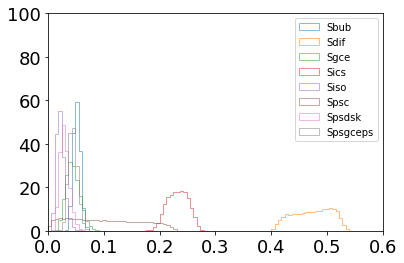

In [38]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('S')])
S_labels = np.array([k for k,v in posterior.items() if k.startswith('S')])

flux_fraction_post = S_post / np.sum(S_post, axis=0)[None, :]

ff_max = 0.6
ff_bins = 100

bins = np.linspace(0, ff_max, ff_bins)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True, alpha=0.5)
    
plt.xlim(0, ff_max)
plt.ylim(0, 100)
plt.legend()

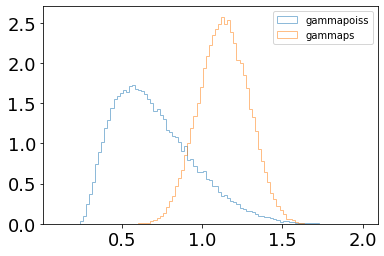

In [39]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('gamma')])
S_labels = np.array([k for k,v in posterior.items() if k.startswith('gamma')])

flux_fraction_post = S_post

bins = np.linspace(0.1, 2., 100)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True, alpha=0.5)
    
plt.legend()

In [ ]:
temps_include = ['Sps_gceps', 'S_gce', 'gamma_poiss', 'gamma_ps']
S_post = np.array([v for k,v  in posterior.items() if k in temps_include])
S_labels = np.array([k for k,v  in posterior.items() if k in temps_include])

corner.corner(S_post.T, labels=[t.replace("_", "") for t in S_labels]);

In [ ]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('zs')])
S_labels = np.array([k for k,v in posterior.items() if k.startswith('zs')])

flux_fraction_post = S_post

bins = np.linspace(0.1, 2.5, 100)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True, alpha=0.5)
    
plt.legend()

In [ ]:
S_post = np.array([v for k,v in posterior.items() if k.startswith('f_bulge')])
S_labels = np.array([k for k,v in posterior.items() if k.startswith('f_bulge')])

flux_fraction_post = S_post

bins = np.linspace(0., 1., 50)
for i in range(len(flux_fraction_post)):
    plt.hist(flux_fraction_post[i], bins=bins, label=S_labels[i].replace("_", ""), histtype='step', density=True, alpha=0.5)
    
plt.legend()

In [423]:
# corner.corner(arviz_post);

In [145]:
# from numpyro.infer import MCMC, HMCECS, NUTS, Predictive

In [146]:
# nuts_kernel = NUTS(model, dense_mass=True, max_tree_depth=3)
# kernel = HMCECS(nuts_kernel, num_blocks=10)

# mcmc = MCMC(kernel, num_samples=4000, num_warmup=500)
# rng_key = random.PRNGKey(0)
# mcmc.run(rng_key, data, subsample_size=int(0.8 * len(data[~mask_roi])))

In [147]:
# arviz_post = az.from_dict(mcmc.get_samples())
# corner.corner(arviz_post);

In [116]:
theta_og = jnp.array([[ 0.1,  3.00000000e+00,  1.99993943e+00, -4.99413650e+00,
   4.00000000e+01,  1.00000000e+00],
 [ 0.1,  3.63483326e+00,  1.78279512e+00, -5.00000000e+00,
   3.89567333e+01,  2.31723543e+00]], dtype=jnp.float64)

theta = []

temp_gce_jax = temp_gce_ps_jax = get_NFW2_template(gamma=1.1)
temp_dsk_jax = get_lorimer_template(zs=1.2, B=3, C=11)

npt_compressed = jnp.array([temp_gce_ps_jax[~mask_roi], temp_dsk_jax[~mask_roi]])

for ips in range(2):
    
    theta_tmp = theta_og[ips]
    theta_tmp = theta_tmp.at[0].set(1.)

    s_ary = jnp.logspace(0., 2, 1000)
    dnds_ary = dnds(s_ary, theta_tmp)

    A = theta_og[ips][0] / jnp.mean(npt_compressed[ips] * jnp.trapz(s_ary * dnds_ary, s_ary))
    
    theta_tmp = theta_tmp.at[0].set(A)

    theta.append(theta_tmp)

theta = jnp.array(theta)

mu = jnp.array(1 * temp_gce_jax + 0.5 * temp_iso + 9. * temp_mO_pibrem + 4. * temp_mO_ics + 0.5 * temp_psc + 1. * temp_bub)

npt_compressed = jnp.array([temp_gce_jax[~mask_roi], temp_dsk_jax[~mask_roi]])

def ll_test(theta):
    return jnp.sum((log_like_np_jax(theta, mu[~mask_roi], npt_compressed, data[~mask_roi], f_ary, df_rho_div_f_ary, k_max, npixROI)))

log_like_np_jax_grad = value_and_grad(ll_test)
log_like_np_jax_grad(theta)

(DeviceArray(-19149.37080393, dtype=float64),
 DeviceArray([[ 4.90714931e+05, -4.37572649e-01,  1.94361790e+01,
                0.00000000e+00,  8.28857748e-01,  3.55271368e-15],
              [ 1.99159445e+03,  3.17008724e-02,  2.61180129e-02,
               -2.90900475e-02,  1.61211819e-01,  5.78886936e-01]],            dtype=float64))

In [ ]:
from models.scd import dnds

theta = jnp.array([[1e-5, 2., -1.3, -1., 10., 2.]] * 2, dtype=jnp.float64)

s_ary = jnp.logspace(-2, 2, 100)
dnds_ary = dnds(s_ary, theta[0])
jnp.mean(npt_compressed[0] * jnp.trapz(s_ary * dnds_ary, s_ary))